In [1]:
from datetime import datetime, time
import pandas as pd
import numpy as np
from itertools import product
from Strategies.Modular_strategy.calibration import ModularStrategyCalibration
from Strategies.Modular_strategy.backtest_class import BacktestModular
from Strategies.Modular_strategy.strategy_class_no_trailing import ModularStrategy as Strategy
from Strategies.Sparse_momentum.ob_attributes import OB_attributes, TR_attributes


import pickle
from Strategies.Modular_strategy.features import *
from Strategies.Sparse_momentum.ob_attributes import OB_attributes
from OrderBook.OrderBook import OrderBookSnaps
from SynthSpread.spreadviewer_class import SpreadSingle
from Database.TPData import TPData, TPDataDa
from Utilities.excel_loaders import conn_out_xload
from Utilities.dfutils import date_filter
from Utilities.Storage import get_curr_storage_path

In [2]:
def clean_ba_dupl(df_input):
    df = df_input[['b_price', 'a_price', 'trd_price']].copy()
    df['b_price_lag'] = df['b_price'].shift(1)
    df['a_price_lag'] = df['a_price'].shift(1)
    df['mask'] = (
        (df['b_price_lag'] != df['b_price']) |
        (df['a_price_lag'] != df['a_price']) |
        (~df['trd_price'].isna())
    )
    return df['mask']

In [3]:
_STORAGE = get_curr_storage_path()
# df_data = pd.read_parquet(_STORAGE + DIR_PATH + f'backtest_obt_{_INSTRUMENT}.parquet')
df_data = pd.read_parquet(_STORAGE + 'data_factory/' + f'backtest_obt_dey1.parquet')
df_data = df_data[~df_data['b_price'].isna()]
df_data = df_data[clean_ba_dupl(df_data)]
df_data = df_data.reset_index(names='timestamp')
df_data['ba_spread'] = (df_data['a_price'] - df_data['b_price']).round(2)
df_data.loc[df_data['trd_price'] > 0, 'trd_vol'] = 1
day = datetime(2025, 1, 24).date()
df_data = df_data[df_data['timestamp'].dt.date != day]

df_data.reset_index(inplace=True, drop=True)
df_data.reset_index(names='index', inplace=True)
df = df_data

In [4]:
ohlc_daily_copy = df[df['trd_price'] > 0].set_index('timestamp')['trd_price'].resample('1B').ohlc()
ohlc_daily_copy['daily_change_direction'] = np.sign(ohlc_daily_copy['close'].diff())
ohlc_daily_copy.dropna(subset=['daily_change_direction'], inplace=True)
ohlc_daily_copy['sequence_group'] = (ohlc_daily_copy['daily_change_direction'] != ohlc_daily_copy['daily_change_direction'].shift()).cumsum()
ohlc_daily_copy['sequence_day_number'] = ohlc_daily_copy.groupby('sequence_group').cumcount() + 1

In [5]:
daily_feats = ohlc_daily_copy[['daily_change_direction', 'sequence_day_number']].shift()
daily_feats['dayweek'] = daily_feats.index.day_of_week
daily_feats['date'] = daily_feats.index.date

In [6]:
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

In [7]:
trades = df[df['trd_price'] > 0].reset_index()[['timestamp', 'trd_price']]

In [8]:
trades['seq_inc'] = (trades['trd_price'].diff() > 0).rolling(5).sum()
trades['seq_dec'] = (trades['trd_price'].diff() < 0).rolling(5).sum()


In [9]:
trades

,timestamp,trd_price,seq_inc,seq_dec
0,2024-07-01 09:00:45.018584017,92.49,NaN,NaN
1,2024-07-01 09:01:23.361109946,92.50,NaN,NaN
2,2024-07-01 09:01:33.327164668,92.65,NaN,NaN
3,2024-07-01 09:02:41.013466312,92.76,NaN,NaN
4,2024-07-01 09:02:50.727503969,92.94,4.0,0.0
...,...,...,...,...
92612,2025-05-09 17:35:43.299029103,86.60,2.0,2.0
92613,2025-05-09 17:36:23.273771254,86.67,3.0,1.0
92614,2025-05-09 17:36:50.478790502,86.66,3.0,1.0
92615,2025-05-09 17:36:50.485527488,86.65,2.0,2.0


In [10]:
df['seq_inc'] = pd.merge(df[['timestamp']], trades[['timestamp', 'seq_inc']], on='timestamp', how='inner')['seq_inc']
df['seq_dec'] = pd.merge(df[['timestamp']], trades[['timestamp', 'seq_dec']], on='timestamp', how='inner')['seq_dec']

In [11]:
df_backtest = pd.merge(df, daily_feats, on='date', how='outer')

In [20]:
    # best params [0.4, 0.19, 0.08, 0.51, 1.0]
    # best closing ['0.75', '0.4', '0.1', '30']
backtest_class = BacktestModular()
# params
fixed_params = {
    'make_profit_margin': 0.5,
    'stop_loss': 0.3,
    'stop_profit': 0.1,
    'burnout_period': 400,
    'makeagg_ratio': 0.6,
    'br_fee': 0.03 / 2,
    't_end': time(17, 15),
    'hard_sl': 0.01,
    'hard_tp': 0.01,
    'closing_mode': 'Other',
    'close_trade_info': None
}
strategy_columns = df_backtest.columns.values

features_pool = {
    'feature_direction': FeatureDailyChangeDirection,
    'feature_sequence': FeatureSeqDay,
    'feature_dayweek': FeatureDayWeek,
    'feature_ba_spread': FeatureBASpread,
    'feature_dayhour': FeatureDayHour,
    'feature_order_t1': FeatureOrderT1,
    'feature_direction': FeatureDirection,
    'feature_seq_direction': FeatureSeqInDirection,
}

params = {
    'feature_direction': {'active': False, 'params': {'thold': 0.0}, 'suffix': ""},
    'feature_sequence': {'active': False, 'params': {'thold': 2}, 'suffix': ""},
    'feature_dayweek': {'active': False, 'params': {'thold': 4}, 'suffix': ""},
    'feature_ba_spread': {'active': False, 'params': {'thold': 0.11}, 'suffix': ""},
    'feature_dayhour': {'active': True, 'params': {'thold': 9}, 'suffix': ""},
    'feature_order_t1': {'active': True, 'suffix': ""},
    'feature_direction': {'active': True, 'params': {'thold': 1}, 'suffix': ""},
    'feature_seq_direction': {'active': True, 'params': {'thold': 3}, 'suffix': ""}
}

In [13]:
data_columns = [
'daily_change_direction',
'sequence_day_number',
'dayweek',
'bid_t1',
'ask_t1',
'ba_spread']
indices = df_backtest[df_backtest[data_columns].notnull().all(axis=1)].index.tolist()

In [21]:
# params = from_key_to_params([0.65, 0.06, 0.82, -0.01, 0.0, 2.0, -1.1, -0.5, 0.4, 1.0], fixed_params, features_pool)

strategy = Strategy(features_pool, strategy_columns,
                        {**params, **fixed_params},
                        lead_closing=False, max_position=1)
backtest_class.simulate_strategy(strategy, df_backtest, indices, cached_returns=None)
xx = backtest_class.calc_returns_new(strategy)

In [23]:
xx

,timestamp,position,action,open_price,price_level,returns
0,2024-07-03 09:12:59.153742780,1.0,1.0,94.00,94.00,0.00
1,2024-07-03 09:22:12.882000000,0.0,-1.0,94.00,93.60,-0.40
2,2024-07-04 09:03:07.800076203,1.0,1.0,93.10,93.10,NaN
3,2024-07-04 11:20:15.540416350,0.0,-1.0,93.10,93.58,0.48
4,2024-07-05 11:02:35.519716271,1.0,1.0,93.34,93.34,NaN
5,2024-07-05 11:20:27.430894363,0.0,-1.0,93.34,93.19,-0.15
6,2024-07-08 10:51:05.940583705,1.0,1.0,94.10,94.10,NaN
7,2024-07-08 12:02:46.133000000,0.0,-1.0,94.10,93.65,-0.45
8,2024-07-09 09:25:55.913952103,1.0,1.0,91.25,91.25,NaN
9,2024-07-09 09:37:47.680000000,0.0,-1.0,91.25,90.91,-0.34


Accuracy: 0.2


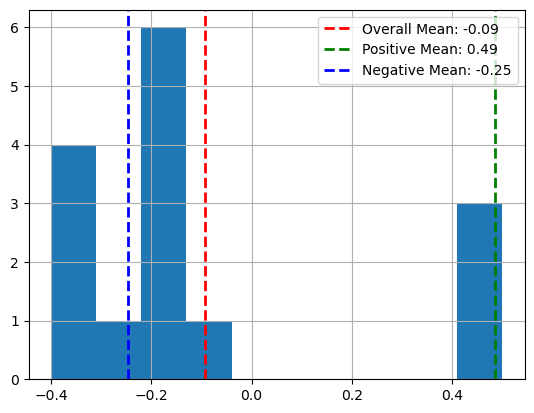

<Axes: >

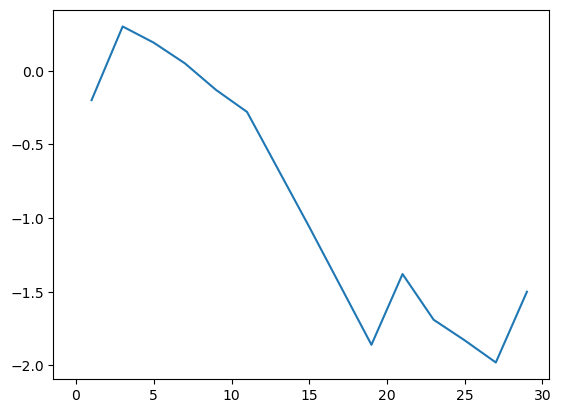

In [19]:
import matplotlib.pyplot as plt

# Assuming 'xx' is a DataFrame and 'returns' is a column in it
overall_mean = xx['returns'].mean()
positive_mean = xx[xx['returns'] > 0]['returns'].mean()
negative_mean = xx[xx['returns'] < 0]['returns'].mean()

# Print accuracy
accuracy = sum(xx['returns'] > 0) / (len(xx)/2)
print('Accuracy:', accuracy)

# Plot histogram
xx[abs(xx['returns']) >= 0.01]['returns'].hist()

# Add vertical lines
plt.axvline(overall_mean, color='r', linestyle='dashed', linewidth=2, label=f'Overall Mean: {overall_mean:.2f}')
plt.axvline(positive_mean, color='g', linestyle='dashed', linewidth=2, label=f'Positive Mean: {positive_mean:.2f}')
plt.axvline(negative_mean, color='b', linestyle='dashed', linewidth=2, label=f'Negative Mean: {negative_mean:.2f}')

# Add a legend
plt.legend()

# Show plot
plt.show()

xx[xx['action'] == -1]['returns'].dropna().cumsum().plot(label='short')
xx[xx['action'] == 1]['returns'].dropna().cumsum().plot()



In [ ]:
xx

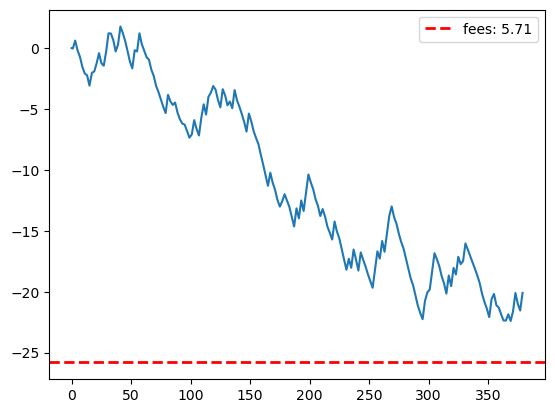

In [38]:
import matplotlib.pyplot as plt

fees = (abs(xx.iloc[0]['position']) + abs(xx['action']).sum())*fixed_params['br_fee']
plt.plot(xx['returns'].dropna().cumsum())
plt.axhline(xx['returns'].sum()-fees, color='r', linestyle='dashed', linewidth=2, label=f'fees: {fees:.2f}')
# Add a legend
plt.legend()

# Show plot
plt.show()

In [40]:
trades_backtest

,timestamp,position,action,price_level,open_price
0,2024-07-03 09:05:28.216126004,1.0,1.0,93.55,93.55
1,2024-07-03 09:11:19.559344388,0.0,-1.0,93.95,NaN
2,2024-07-04 09:42:49.919794516,1.0,1.0,93.10,93.10
3,2024-07-04 11:17:00.022357207,0.0,-1.0,93.50,NaN
4,2024-07-05 09:10:23.854536972,1.0,1.0,94.50,94.50
...,...,...,...,...,...
375,2025-05-07 09:29:37.467000000,0.0,-1.0,85.70,NaN
376,2025-05-08 09:06:32.131671528,1.0,1.0,87.40,87.40
377,2025-05-08 09:09:19.882344823,0.0,-1.0,87.78,NaN
378,2025-05-09 09:01:00.629630829,1.0,1.0,88.00,88.00


In [39]:
import plotly.graph_objects as go
from Utilities.dfutils import show_in_window

trades_backtest = pd.DataFrame(strategy.stats_dict)

df_ob = df_data.copy().dropna(subset=['trd_price'])
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_ob['timestamp'].tolist(), y=df_ob['trd_price'], mode='markers'))
fig.add_trace(go.Scatter(x=trades_backtest['timestamp'].tolist(), y=trades_backtest['price_level'], mode='markers', marker=dict(symbol='diamond', size=20, color=np.sign(trades_backtest.action))))
# fig.add_trace(go.Scatter(x=trades['timestamp'].tolist(), y=trades['price'], mode='markers', marker=dict(symbol='x', size=20, color=np.sign(trades.action))))

show_in_window(fig)

/opt/homebrew/Caskroom/miniconda/base/envs/develop/lib/python3.11/site-packages/plotly/io/_json.py:560: UserWarning:

Discarding nonzero nanoseconds in conversion.



In [ ]:
xx = backtest_class.calc_returns_new(strategy)

xx['returns_shift'] = xx['returns'].shift(-1)
neg_ret = xx[xx['returns_shift'] < -0.1][['timestamp', 'position']]
pos_ret = xx[xx['returns_shift'] > 0.2][['timestamp', 'position']]
filtered_df = df_data.reindex(backtest_class.open_positions_idxs)

In [ ]:
filtered_df

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
feature_cols = ['timestamp',
    
]
def map_to_unit_interval(series):
    try:
        lower_bound = series.min()
        upper_bound = series.max()
        return (series - lower_bound) / (upper_bound - lower_bound + 1e-6)  # Avoid division by zero
    except:
        return series
    
def z_scale(series):
    return (series - series.mean()) / series.std()
    
feature_cols = list((set(feature_cols) - {'timestamp'}))
rescaled_df = filtered_df[feature_cols].apply(map_to_unit_interval)
rescaled_df['timestamp'] = filtered_df['timestamp']
long_pos = get_predictors_for_posistions(rescaled_df, pos_ret[pos_ret['position'] > 0]['timestamp'])
long_neg = get_predictors_for_posistions(rescaled_df, neg_ret[neg_ret['position'] > 0]['timestamp'])

short_pos = get_predictors_for_posistions(rescaled_df, pos_ret[pos_ret['position'] < 0]['timestamp'])
short_neg = get_predictors_for_posistions(rescaled_df, neg_ret[neg_ret['position'] < 0]['timestamp'])

# Adding category labels
long_pos['Category'] = 'long_pos'
long_neg['Category'] = 'long_neg'

# Combine long dataframes
long_data = pd.concat([long_pos, long_neg])

# Melt the combined dataframe
long_melted = long_data[[*feature_cols, 'Category']].melt(id_vars='Category', var_name='Feature', value_name='Value')

# Plot the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x='Feature', y='Value', hue='Category', data=long_melted)
plt.title("Long Positions")
plt.xlabel('Feature Names')
plt.ylabel('value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.ylim(-0.2, 1.2)
plt.show()

# Adding category labels
short_pos['Category'] = 'short_pos'
short_neg['Category'] = 'short_neg'

# Combine long dataframes
short_data = pd.concat([short_pos, short_neg])

# Melt the combined dataframe
short_melted = short_data[[*feature_cols, 'Category']].melt(id_vars='Category', var_name='Feature', value_name='Value')

# Plot the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x='Feature', y='Value', hue='Category', data=short_melted)
plt.title("Short Positions")
plt.xlabel('Feature Names')
plt.ylabel('value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.ylim(-0.2, 1.2)
plt.show()